# 10 — Spin-orbit coupling analysis

Compare parsed ORCA spin-orbit coupling matrix elements between singlet and triplet excited states, identify dominant S1-triplet ISC channels, and generate publication-ready SOC summary figures.


## A. Load and validate parsed SOC data


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Make figures independent of PyCharm/Jupyter dark-theme defaults.
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "font.family": "DejaVu Sans",
    }
)

ROOT = Path("..").resolve()
RESULTS = ROOT / "results" / "excited_state" / "soc"
FIGURES = ROOT / "figures" / "soc"
FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

SYSTEM_ORDER = ["pdi", "pdi_terminal_functionalized"]
SYSTEM_LABELS = {
    "pdi": "Parent PDI",
    "pdi_terminal_functionalized": "Functionalized PDI",
}
SYSTEM_COLORS = {
    "pdi": "#0018F9",
    "pdi_terminal_functionalized": "#F28500",
}
SOC_FILES = {
    "pdi": RESULTS / "pdi_soc.csv",
    "pdi_terminal_functionalized": RESULTS / "pdi_terminal_functionalized_soc.csv",
}

missing_files = [str(path) for path in SOC_FILES.values() if not path.is_file()]
if missing_files:
    raise FileNotFoundError(
        "Run scripts.postprocess.excited_states.parse_soc.py before this notebook. "
        f"Missing files: {missing_files}"
    )

soc_tables = []
for system, path in SOC_FILES.items():
    table = pd.read_csv(path)
    table["system"] = system
    table["system_label"] = SYSTEM_LABELS[system]
    table["source_file"] = str(path.relative_to(ROOT))
    soc_tables.append(table)

soc = pd.concat(soc_tables, ignore_index=True)
soc["soc_cm1"] = pd.to_numeric(soc["soc_cm-1"], errors="coerce")
soc["singlet_label"] = "S" + soc["singlet"].astype(int).astype(str)
soc["triplet_label"] = "T" + soc["triplet"].astype(int).astype(str)
soc["pair_label"] = soc["singlet_label"] + "-" + soc["triplet_label"]

display(soc.head())


,triplet,singlet,x_re,x_im,y_re,y_im,z_re,z_im,soc_cm-1,system,system_label,source_file,soc_cm1,singlet_label,triplet_label,pair_label
0,1,0,0.0,-0.00,0.0,0.01,-0.0,0.00,0.010000,pdi,Parent PDI,results/excited_state/soc/pdi_soc.csv,0.010000,S0,T1,S0-T1
1,1,1,0.0,-0.00,0.0,-0.00,-0.0,0.09,0.090000,pdi,Parent PDI,results/excited_state/soc/pdi_soc.csv,0.090000,S1,T1,S1-T1
2,1,2,0.0,-0.00,0.0,0.01,-0.0,0.04,0.041231,pdi,Parent PDI,results/excited_state/soc/pdi_soc.csv,0.041231,S2,T1,S2-T1
3,1,3,0.0,0.01,0.0,0.19,-0.0,0.00,0.190263,pdi,Parent PDI,results/excited_state/soc/pdi_soc.csv,0.190263,S3,T1,S3-T1
4,1,4,0.0,-0.00,0.0,-0.00,-0.0,-0.03,0.030000,pdi,Parent PDI,results/excited_state/soc/pdi_soc.csv,0.030000,S4,T1,S4-T1


In [2]:
def style_white_axes(fig, ax):
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.tick_params(
        axis="both",
        colors="black",
        labelsize=14,
        width=1.8,
        direction="in",
    )

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.8)


def practical_chemistry_axis(
    ax,
    xlabel=None,
    ylabel=None,
    title=None,
    legend=False,
    legend_loc="best",
):
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=22, fontweight="bold")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=22, fontweight="bold")
    if title:
        ax.set_title(title, fontsize=18, fontweight="bold", pad=12)
    if legend:
        leg = ax.legend(loc=legend_loc, frameon=True, fontsize=10)
        leg.get_frame().set_edgecolor("black")
        leg.get_frame().set_linewidth(1.0)
        leg.get_frame().set_facecolor("white")
        for text in leg.get_texts():
            text.set_fontweight("bold")
    style_white_axes(ax.figure, ax)


def save_figure(fig, stem):
    fig.savefig(FIGURES / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIGURES / f"{stem}.png", dpi=300, bbox_inches="tight")


def annotate_bars(ax, bars, fmt="{:.2f}", padding_fraction=0.025):
    ymin, ymax = ax.get_ylim()
    padding = padding_fraction * (ymax - ymin)

    for bar in bars:
        height = bar.get_height()
        if not np.isfinite(height):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + padding,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="black",
        )


In [3]:
required_columns = {
    "triplet",
    "singlet",
    "x_re",
    "x_im",
    "y_re",
    "y_im",
    "z_re",
    "z_im",
    "soc_cm-1",
    "system",
}
missing_columns = required_columns - set(soc.columns)
if missing_columns:
    raise ValueError(f"Missing columns in SOC table: {sorted(missing_columns)}")

if soc["soc_cm1"].isna().any():
    raise ValueError("Some SOC values could not be converted to numeric values.")

if set(soc["system"]) != set(SYSTEM_ORDER):
    raise ValueError(f"Unexpected systems in SOC table: {sorted(soc['system'].unique())}")

summary = (
    soc.groupby(["system", "system_label"])
    .agg(
        number_of_couplings=("soc_cm1", "size"),
        number_of_singlets=("singlet", "nunique"),
        number_of_triplets=("triplet", "nunique"),
        maximum_soc_cm1=("soc_cm1", "max"),
        mean_soc_cm1=("soc_cm1", "mean"),
        median_soc_cm1=("soc_cm1", "median"),
    )
    .reset_index()
)
summary["maximum_soc_cm1"] = summary["maximum_soc_cm1"].round(3)
summary["mean_soc_cm1"] = summary["mean_soc_cm1"].round(3)
summary["median_soc_cm1"] = summary["median_soc_cm1"].round(3)

display(summary)


,system,system_label,number_of_couplings,number_of_singlets,number_of_triplets,maximum_soc_cm1,mean_soc_cm1,median_soc_cm1
0,pdi,Parent PDI,110,11,10,62.212,1.466,0.095
1,pdi_terminal_functionalized,Functionalized PDI,110,11,10,62.152,2.274,0.118


## B. S1-triplet SOC comparison


In [4]:
s1_soc = soc[soc["singlet"] == 1].copy()
s1_soc = s1_soc.sort_values(["system", "triplet"])

s1_summary = s1_soc[
    [
        "system",
        "system_label",
        "singlet_label",
        "triplet_label",
        "pair_label",
        "soc_cm1",
    ]
].copy()
s1_summary["soc_cm1"] = s1_summary["soc_cm1"].round(6)
s1_summary.to_csv(RESULTS / "s1_triplet_soc_summary.csv", index=False)

display(s1_summary)


,system,system_label,singlet_label,triplet_label,pair_label,soc_cm1
1,pdi,Parent PDI,S1,T1,S1-T1,0.090000
12,pdi,Parent PDI,S1,T2,S1-T2,0.014142
23,pdi,Parent PDI,S1,T3,S1-T3,0.010000
34,pdi,Parent PDI,S1,T4,S1-T4,0.000000
45,pdi,Parent PDI,S1,T5,S1-T5,0.078102
56,pdi,Parent PDI,S1,T6,S1-T6,0.071414
67,pdi,Parent PDI,S1,T7,S1-T7,0.028284
78,pdi,Parent PDI,S1,T8,S1-T8,0.072801
89,pdi,Parent PDI,S1,T9,S1-T9,10.630489
100,pdi,Parent PDI,S1,T10,S1-T10,0.022361


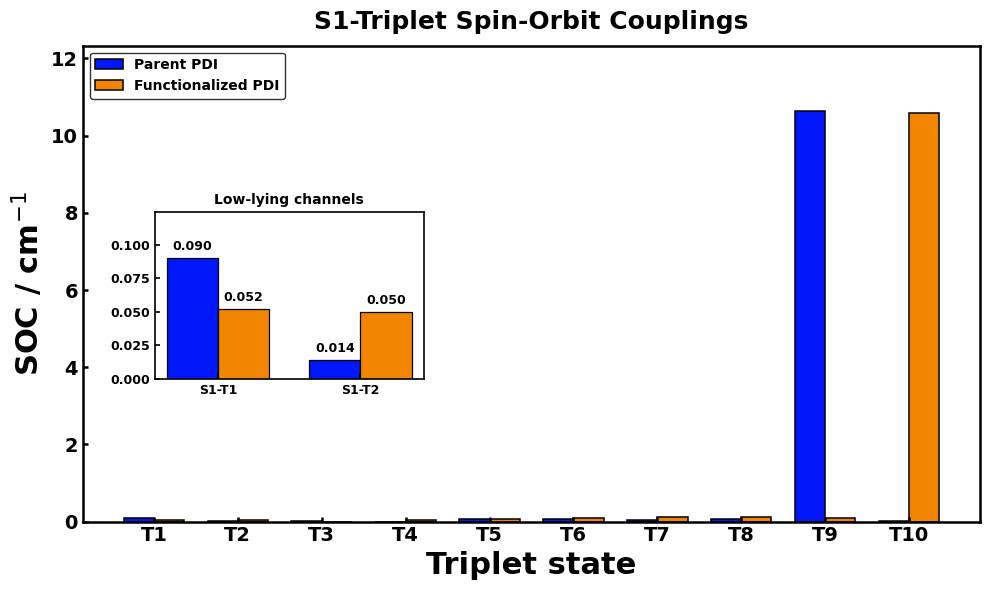

In [5]:
triplets = sorted(s1_soc["triplet"].unique())
low_state_soc = s1_soc[s1_soc["triplet"].isin([1, 2])].copy()

fig, ax = plt.subplots(figsize=(10, 6.0), facecolor="white")
x = np.arange(len(triplets), dtype=float)
width = 0.36

for offset, system in zip([-width / 2, width / 2], SYSTEM_ORDER, strict=True):
    subset = s1_soc[s1_soc["system"] == system].set_index("triplet")
    values = [subset.loc[triplet, "soc_cm1"] for triplet in triplets]
    ax.bar(
        x + offset,
        values,
        width=width,
        color=SYSTEM_COLORS[system],
        edgecolor="black",
        linewidth=1.1,
        label=SYSTEM_LABELS[system],
    )

ax.set_xticks(x)
ax.set_xticklabels([f"T{triplet}" for triplet in triplets])
ax.set_ylim(0, s1_soc["soc_cm1"].max() * 1.16)
practical_chemistry_axis(
    ax,
    xlabel="Triplet state",
    ylabel=r"SOC / cm$^{-1}$",
    title="S1-Triplet Spin-Orbit Couplings",
    legend=True,
    legend_loc="upper left",
)

inset = ax.inset_axes([0.08, 0.3, 0.3, 0.35])
inset_x = np.arange(2, dtype=float)
for offset, system in zip([-width / 2, width / 2], SYSTEM_ORDER, strict=True):
    subset = low_state_soc[low_state_soc["system"] == system].set_index("triplet")
    bars = inset.bar(
        inset_x + offset,
        [subset.loc[1, "soc_cm1"], subset.loc[2, "soc_cm1"]],
        width=width,
        color=SYSTEM_COLORS[system],
        edgecolor="black",
        linewidth=0.9,
    )
    annotate_bars(inset, bars, fmt="{:.3f}", padding_fraction=0.040)

inset.set_xticks(inset_x)
inset.set_xticklabels(["S1-T1", "S1-T2"], fontsize=8, fontweight="bold")
inset.set_ylim(0, low_state_soc["soc_cm1"].max() * 1.38)
inset.set_title("Low-lying channels", fontsize=10, fontweight="bold", pad=6)
inset.tick_params(
    axis="both",
    colors="black",
    labelsize=9,
    width=1.2,
    direction="in",
)
for label in inset.get_yticklabels():
    label.set_fontweight("bold")
for spine in inset.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.2)
inset.set_facecolor("white")

plt.tight_layout()
save_figure(fig, "s1_triplet_soc_comparison")
plt.show()


## C. SOC-energy-gap screening


In [6]:
TDA_RESULTS = ROOT / "results" / "excited_state" / "tda_uv_vis"
EXCITATION_STATES_FILE = TDA_RESULTS / "excitation_states.csv"

if not EXCITATION_STATES_FILE.is_file():
    raise FileNotFoundError(
        "Run scripts.postprocess.excited_states.parse_tda_calculations before this notebook. "
        f"Missing file: {EXCITATION_STATES_FILE}"
    )

excitation_states = pd.read_csv(EXCITATION_STATES_FILE)
required_energy_columns = {
    "system",
    "multiplicity",
    "state_index",
    "state_label",
    "excitation_energy_ev",
}
missing_energy_columns = required_energy_columns - set(excitation_states.columns)
if missing_energy_columns:
    raise ValueError(
        "Missing columns in excitation_states.csv: "
        f"{sorted(missing_energy_columns)}"
    )

s1_energies = (
    excitation_states[
        (excitation_states["multiplicity"] == "singlet")
        & (excitation_states["state_label"] == "S1")
    ][["system", "excitation_energy_ev"]]
    .rename(columns={"excitation_energy_ev": "s1_energy_ev"})
    .copy()
)
triplet_energies = (
    excitation_states[excitation_states["multiplicity"] == "triplet"]
    [["system", "state_index", "state_label", "excitation_energy_ev"]]
    .rename(
        columns={
            "state_index": "triplet",
            "state_label": "triplet_label_from_tda",
            "excitation_energy_ev": "triplet_energy_ev",
        }
    )
    .copy()
)

s1_energy_screening = (
    s1_soc.merge(s1_energies, on="system", how="left")
    .merge(triplet_energies, on=["system", "triplet"], how="left")
    .copy()
)

if s1_energy_screening[["s1_energy_ev", "triplet_energy_ev"]].isna().any().any():
    raise ValueError("S1 or triplet energies could not be matched to the SOC table.")

s1_energy_screening["delta_e_s1_minus_tn_ev"] = (
    s1_energy_screening["s1_energy_ev"]
    - s1_energy_screening["triplet_energy_ev"]
)
s1_energy_screening["absolute_delta_e_ev"] = s1_energy_screening[
    "delta_e_s1_minus_tn_ev"
].abs()
s1_energy_screening["soc_squared_over_delta_e_squared"] = np.where(
    s1_energy_screening["absolute_delta_e_ev"] > 1e-12,
    s1_energy_screening["soc_cm1"] ** 2
    / s1_energy_screening["absolute_delta_e_ev"] ** 2,
    np.nan,
)

screening_columns = [
    "system",
    "system_label",
    "pair_label",
    "s1_energy_ev",
    "triplet_energy_ev",
    "delta_e_s1_minus_tn_ev",
    "absolute_delta_e_ev",
    "soc_cm1",
    "soc_squared_over_delta_e_squared",
]

s1_energy_screening[screening_columns].to_csv(
    RESULTS / "s1_triplet_soc_energy_gap_screening.csv",
    index=False,
)

display(
    s1_energy_screening[screening_columns]
    .sort_values(["system", "soc_squared_over_delta_e_squared"], ascending=[True, False])
    .round(4)
)


,system,system_label,pair_label,s1_energy_ev,triplet_energy_ev,delta_e_s1_minus_tn_ev,absolute_delta_e_ev,soc_cm1,soc_squared_over_delta_e_squared
8,pdi,Parent PDI,S1-T9,2.7635,4.341,-1.5775,1.5775,10.6305,45.4103
4,pdi,Parent PDI,S1-T5,2.7635,3.388,-0.6245,0.6245,0.0781,0.0156
0,pdi,Parent PDI,S1-T1,2.7635,1.617,1.1465,1.1465,0.0900,0.0062
1,pdi,Parent PDI,S1-T2,2.7635,2.949,-0.1855,0.1855,0.0141,0.0058
5,pdi,Parent PDI,S1-T6,2.7635,4.196,-1.4325,1.4325,0.0714,0.0025
7,pdi,Parent PDI,S1-T8,2.7635,4.339,-1.5755,1.5755,0.0728,0.0021
2,pdi,Parent PDI,S1-T3,2.7635,3.078,-0.3145,0.3145,0.0100,0.0010
6,pdi,Parent PDI,S1-T7,2.7635,4.245,-1.4815,1.4815,0.0283,0.0004
9,pdi,Parent PDI,S1-T10,2.7635,4.413,-1.6495,1.6495,0.0224,0.0002
3,pdi,Parent PDI,S1-T4,2.7635,3.294,-0.5305,0.5305,0.0000,0.0000


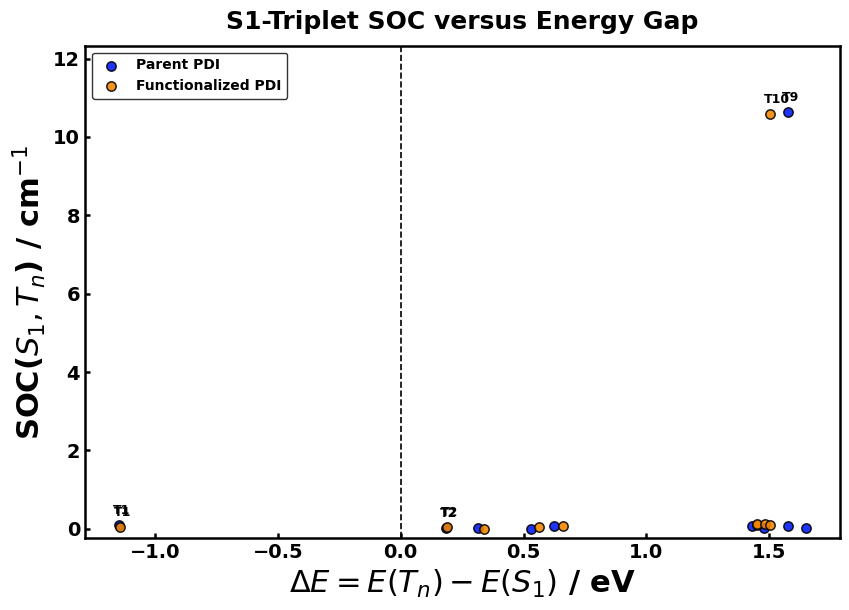

In [7]:
fig, ax = plt.subplots(figsize=(8.6, 6.2), facecolor="white")

for system in SYSTEM_ORDER:
    subset = s1_energy_screening[s1_energy_screening["system"] == system].copy()
    strongest_triplet = subset.loc[subset["soc_cm1"].idxmax(), "triplet"]
    label_triplets = {1, 2, int(strongest_triplet)}

    ax.scatter(
        -subset["delta_e_s1_minus_tn_ev"],
        subset["soc_cm1"],
        s=45,
        color=SYSTEM_COLORS[system],
        edgecolor="black",
        linewidth=1.1,
        alpha=0.88,
        label=SYSTEM_LABELS[system],
    )

    for row in subset.itertuples(index=False):
        if int(row.triplet) not in label_triplets:
            continue
        ax.text(
            -(row.delta_e_s1_minus_tn_ev + 0.025),
            row.soc_cm1 + 0.20,
            row.triplet_label,
            ha="left",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="black",
        )

ax.axvline(0, color="black", linestyle="dashed", linewidth=1.2)
ax.set_ylim(-0.25, s1_energy_screening["soc_cm1"].max() * 1.16)
practical_chemistry_axis(
    ax,
    xlabel=r"$\Delta E = E(T_n)-E(S_1)$ / eV",
    ylabel=r"SOC($S_1,T_n$) / cm$^{-1}$",
    title="S1-Triplet SOC versus Energy Gap",
    legend=True,
    legend_loc="upper left",
)
plt.tight_layout()
save_figure(fig, "s1_triplet_soc_vs_energy_gap")
plt.show()


## D. Dominant SOC channels


In [8]:
dominant_s1_channels = (
    s1_soc.sort_values(["system", "soc_cm1"], ascending=[True, False])
    .groupby("system", as_index=False)
    .head(5)
    .sort_values(["system", "soc_cm1"], ascending=[True, True])
    .copy()
)

dominant_s1_channels[
    [
        "system",
        "system_label",
        "pair_label",
        "soc_cm1",
        "x_re",
        "x_im",
        "y_re",
        "y_im",
        "z_re",
        "z_im",
    ]
].to_csv(RESULTS / "dominant_s1_soc_channels.csv", index=False)

display(
    dominant_s1_channels[
        [
            "system_label",
            "pair_label",
            "soc_cm1",
            "x_re",
            "x_im",
            "y_re",
            "y_im",
            "z_re",
            "z_im",
        ]
    ].round(4)
)


,system_label,pair_label,soc_cm1,x_re,x_im,y_re,y_im,z_re,z_im
56,Parent PDI,S1-T6,0.0714,0.0,-0.01,0.0,0.07,-0.0,0.01
78,Parent PDI,S1-T8,0.0728,0.0,-0.00,0.0,0.07,-0.0,0.02
45,Parent PDI,S1-T5,0.0781,0.0,0.05,0.0,-0.06,-0.0,-0.00
1,Parent PDI,S1-T1,0.0900,0.0,-0.00,0.0,-0.00,-0.0,0.09
89,Parent PDI,S1-T9,10.6305,0.0,0.10,0.0,0.02,-0.0,-10.63
199,Functionalized PDI,S1-T9,0.0819,0.0,-0.07,0.0,-0.03,-0.0,0.03
166,Functionalized PDI,S1-T6,0.1049,0.0,-0.01,0.0,-0.03,-0.0,0.10
177,Functionalized PDI,S1-T7,0.1158,0.0,0.03,0.0,-0.02,-0.0,-0.11
188,Functionalized PDI,S1-T8,0.1304,0.0,0.00,0.0,-0.01,-0.0,-0.13
210,Functionalized PDI,S1-T10,10.5798,0.0,0.01,0.0,1.52,-0.0,-10.47


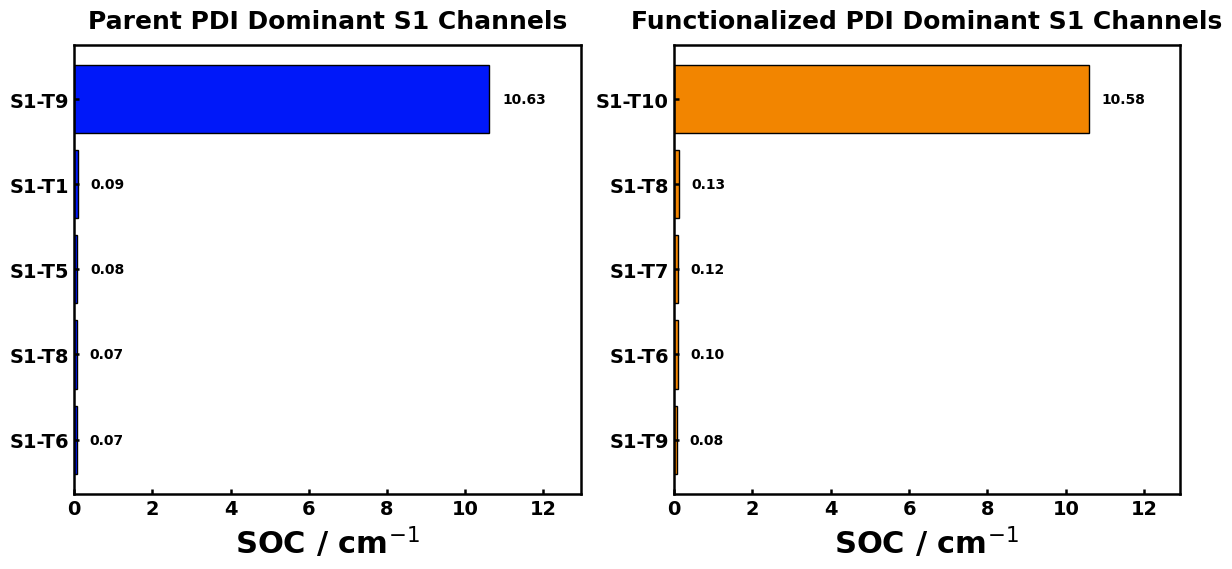

In [9]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12.0, 5.8),
    facecolor="white",
    sharex=False,
)

for ax, system in zip(axes, SYSTEM_ORDER, strict=True):
    subset = dominant_s1_channels[dominant_s1_channels["system"] == system].copy()
    colors = [SYSTEM_COLORS[system] for _ in range(len(subset))]
    bars = ax.barh(
        subset["pair_label"],
        subset["soc_cm1"],
        color=colors,
        edgecolor="black",
        linewidth=1.0,
    )
    ax.set_xlim(0, subset["soc_cm1"].max() * 1.22)
    for bar in bars:
        width_value = bar.get_width()
        ax.text(
            width_value + 0.025 * ax.get_xlim()[1],
            bar.get_y() + bar.get_height() / 2,
            f"{width_value:.2f}",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="black",
        )
    practical_chemistry_axis(
        ax,
        xlabel=r"SOC / cm$^{-1}$",
        title=f"{SYSTEM_LABELS[system]} Dominant S1 Channels",
    )

plt.tight_layout()
save_figure(fig, "dominant_s1_soc_channels")
plt.show()


## E. SOC matrix heatmaps


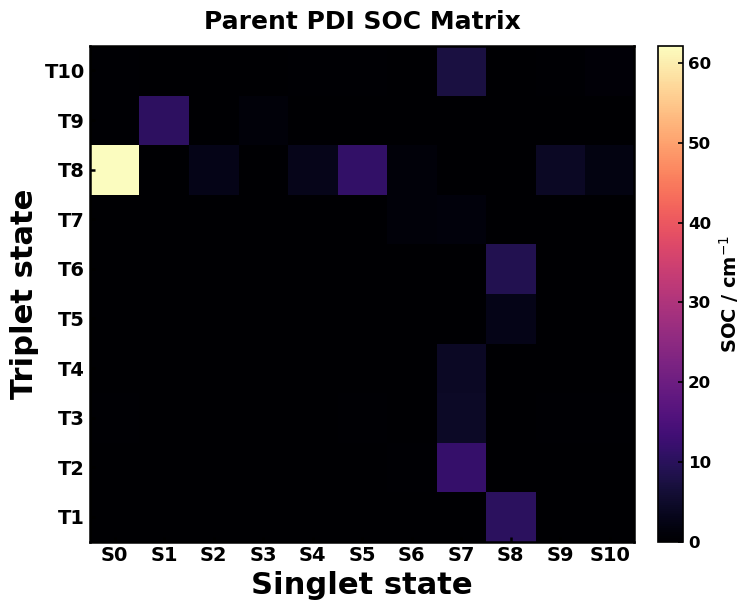

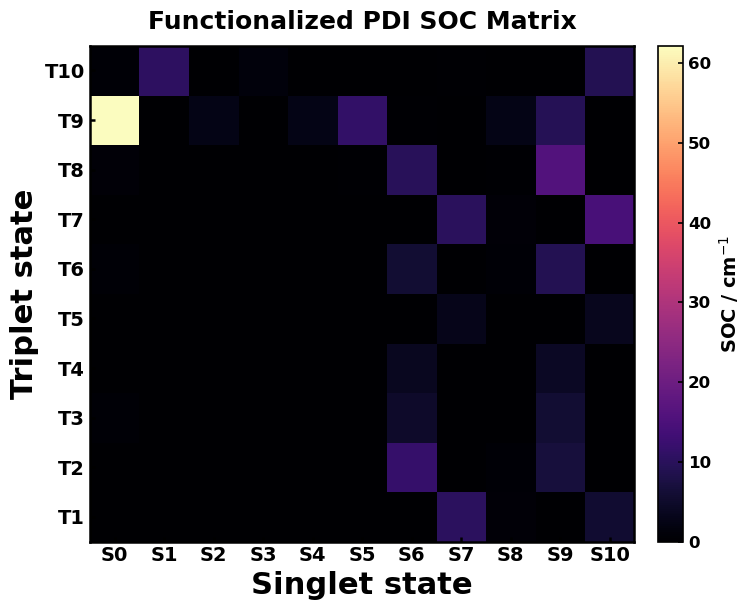

In [10]:
def plot_soc_heatmap(system, vmax):
    matrix = (
        soc[soc["system"] == system]
        .pivot(index="triplet", columns="singlet", values="soc_cm1")
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    fig, ax = plt.subplots(figsize=(7.6, 6.2), facecolor="white")
    image = ax.imshow(
        matrix.to_numpy(),
        origin="lower",
        aspect="auto",
        cmap="magma",
        vmin=0,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_xticklabels([f"S{int(value)}" for value in matrix.columns])
    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_yticklabels([f"T{int(value)}" for value in matrix.index])
    practical_chemistry_axis(
        ax,
        xlabel="Singlet state",
        ylabel="Triplet state",
        title=f"{SYSTEM_LABELS[system]} SOC Matrix",
    )

    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label(r"SOC / cm$^{-1}$", fontsize=14, fontweight="bold")
    colorbar.ax.tick_params(labelsize=12, direction="in", width=1.2, colors="black")
    for label in colorbar.ax.get_yticklabels():
        label.set_fontweight("bold")
    colorbar.outline.set_edgecolor("black")
    colorbar.outline.set_linewidth(1.2)

    plt.tight_layout()
    save_figure(fig, f"{system}_soc_matrix_heatmap")
    plt.show()


matrix_vmax = soc["soc_cm1"].max()
for system in SYSTEM_ORDER:
    plot_soc_heatmap(system, matrix_vmax)


## F. Compact interpretation table


In [11]:
compact_rows = []
for system in SYSTEM_ORDER:
    subset = s1_soc[s1_soc["system"] == system].copy()
    t1 = subset.loc[subset["triplet"] == 1, "soc_cm1"].iloc[0]
    t2 = subset.loc[subset["triplet"] == 2, "soc_cm1"].iloc[0]
    strongest = subset.loc[subset["soc_cm1"].idxmax()]
    compact_rows.append(
        {
            "system": system,
            "system_label": SYSTEM_LABELS[system],
            "S1-T1 SOC / cm^-1": t1,
            "S1-T2 SOC / cm^-1": t2,
            "strongest S1-Tn channel": strongest["pair_label"],
            "strongest S1-Tn SOC / cm^-1": strongest["soc_cm1"],
        }
    )

compact_summary = pd.DataFrame(compact_rows)
for column in compact_summary.columns:
    if "SOC" in column:
        compact_summary[column] = compact_summary[column].round(3)

compact_summary.to_csv(RESULTS / "soc_interpretation_summary.csv", index=False)
display(compact_summary)


,system,system_label,S1-T1 SOC / cm^-1,S1-T2 SOC / cm^-1,strongest S1-Tn channel,strongest S1-Tn SOC / cm^-1
0,pdi,Parent PDI,0.090,0.014,S1-T9,10.63
1,pdi_terminal_functionalized,Functionalized PDI,0.052,0.050,S1-T10,10.58
